# Provided code on how to import data

In [91]:
import h5py
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Polygon

# Open file
filepath = "Mock_worms/chemotaxis_mock_23_1_23_09_20240123_150906\metadata_featuresN_oneworm.hdf5"

with h5py.File(filepath, 'r') as f:
    # List all datasets
    print("Datasets:", list(f.keys()))
    
    # Load trajectories data as DataFrame
    traj_data = pd.DataFrame(f['trajectories_data'][:])
    
    # Load timeseries features (if present)
    if 'timeseries_data' in f:
        timeseries = pd.DataFrame(f['timeseries_data'][:])
    
    # Load odor patch coordinates
    if 'food_cnt_coord' in f:
        odor_patch = f['food_cnt_coord'][:]
        print(f"Odor patch defined by {len(odor_patch)} boundary points")
    
    # Load skeleton coordinates
    coords = f['coordinates']['skeletons'][:]  # Shape: (n_frames, n_segments, 2)

    

Datasets: ['base_coordinates', 'base_x', 'base_y', 'coordinates', 'food_cnt_coord', 'neck_coordinates', 'neck_x', 'neck_y', 'timeseries_data', 'trajectories_data']
Odor patch defined by 1000 boundary points


In [2]:
with h5py.File(filepath, 'r') as f:
    print("Top-level keys:", list(f.keys()))
    
    coord_obj = f['coordinates']
    print("Type of 'coordinates':", type(coord_obj))
    
    if isinstance(coord_obj, h5py.Group):
        print("Keys inside 'coordinates' group:", list(coord_obj.keys()))
        # Now you can load the appropriate dataset, e.g.:
        # coords = coord_obj['skeleton'][:]  # if the dataset is named 'skeleton'
        # or perhaps there are separate x and y datasets.
    elif isinstance(coord_obj, h5py.Dataset):
        # If it were a dataset, your original code would work
        coords = coord_obj[:]



Top-level keys: ['base_coordinates', 'base_x', 'base_y', 'coordinates', 'food_cnt_coord', 'neck_coordinates', 'neck_x', 'neck_y', 'timeseries_data', 'trajectories_data']
Type of 'coordinates': <class 'h5py._hl.group.Group'>
Keys inside 'coordinates' group: ['skeletons']


# single-worm trajectory

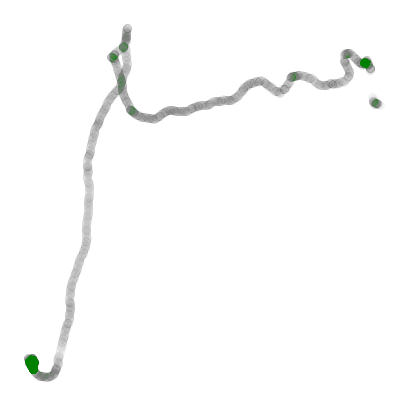

In [22]:
x_pos = np.array(traj_data["coord_x"])
y_pos = np.array(traj_data["coord_y"])


fig, ax = plt.subplots(figsize = (5, 5))

ax.set_axis_off()

plt.scatter(x_pos, y_pos, color = "green", alpha=0.005)


# mock, aversive, sexually-conditioned worm

C:\Users\27503\AppData\Local\Temp\ipykernel_34036\3497433799.py:46: RuntimeWarning: invalid value encountered in scalar divide
  alpha[i, j] = (X[i, j] - x_left) / (x_right - x_left)


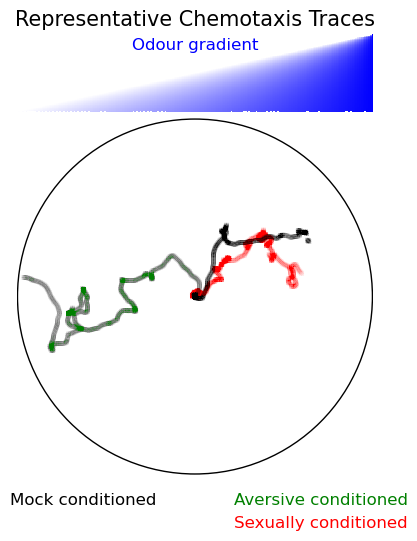

In [117]:
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_axis_off()
ax.set_aspect('equal')

plt.title("Representative Chemotaxis Traces", fontsize = 15, ha = 'center')


# Open file
filepath = ["Mock_worms/chemotaxis_mock_23_1_23_09_20240123_150906\metadata_featuresN_oneworm.hdf5", 
            "Aversive_worms/chemotaxis_avsv_24_1_23_01_20240124_140022/metadata_featuresN_oneworm.hdf5", 
            "sexually_conditioned_worms\chemotaxis_sexc_24_1_26_09_20240126_143858\metadata_featuresN_oneworm.hdf5"]

label_color = ["black", 
         "green", 
         "red"]

for i, item in enumerate(filepath):

    with h5py.File(item, 'r') as f:
        
        # Load trajectories data as DataFrame
        traj_data = pd.DataFrame(f['trajectories_data'][:])


        x_pos = np.array(traj_data["coord_x"])
        y_pos = np.array(traj_data["coord_y"])


        x_init = x_pos[0]
        y_init = y_pos[0]

        plt.scatter(x_pos - x_init, y_pos - y_init, color = label_color[i], s = 10,   alpha = 0.005)


circle_center = (0, 0)
circle_radius = 2300
circle = patches.Circle(circle_center, circle_radius, color='k', fill=False) #

# 3. Add the circle patch to the axes
ax.add_patch(circle)

ax.text(-500, -2700, "Mock conditioned", color = 'k',  ha = 'right',fontsize=12)
ax.text(500, -2700, "Aversive conditioned", color = 'g',  ha = 'left',fontsize=12)
ax.text(500, -3000, "Sexually conditioned", color = 'r',  ha = 'left',fontsize=12)




R = circle_radius
triangle_offset = 100
triangle_height = 1000

# Define triangle vertices
vertices = [(-R, R + triangle_offset), (R, R + triangle_offset), (R, R + triangle_height + triangle_offset)]


triangle_text_offset = -200
ax.text(0, R + triangle_offset + triangle_height + triangle_text_offset, 'Odour gradient', color = 'b', ha = 'center', fontsize = 12)
add_gradient_triangle(ax, vertices, color='blue')

# Create a polygon patch
# triangle = patches.Polygon(vertices, closed=True, edgecolor='none', facecolor='green', linewidth=2)

# Add it to your axes
# ax.add_patch(triangle)



# Silly function to draw triangle

In [115]:
def add_gradient_triangle(ax, vertices, color='green', n_grid=200):
    """
    Adds a triangle with a horizontal gradient (alpha=0 on left, alpha=1 on right).
    
    Parameters
    ----------
    ax : matplotlib Axes
    vertices : list of (x, y) tuples
    color : str or RGB tuple
    n_grid : int, resolution of the gradient grid (higher = smoother)
    """
    # Compute bounding box
    xs = [v[0] for v in vertices]
    ys = [v[1] for v in vertices]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    # Create dense grid
    x = np.linspace(x_min, x_max, n_grid)
    y = np.linspace(y_min, y_max, n_grid)
    X, Y = np.meshgrid(x, y)

    # Point-in-triangle test (barycentric coordinates)
    v0, v1, v2 = vertices
    def point_in_triangle(px, py):
        denom = (v1[1] - v2[1])*(v0[0] - v2[0]) + (v2[0] - v1[0])*(v0[1] - v2[1])
        a = ((v1[1] - v2[1])*(px - v2[0]) + (v2[0] - v1[0])*(py - v2[1])) / denom
        b = ((v2[1] - v0[1])*(px - v2[0]) + (v0[0] - v2[0])*(py - v2[1])) / denom
        c = 1 - a - b
        return (0 <= a <= 1) and (0 <= b <= 1) and (0 <= c <= 1)

    # Vectorized mask
    mask = np.array([[point_in_triangle(X[i,j], Y[i,j]) for j in range(n_grid)] for i in range(n_grid)])

    # Compute alpha: horizontal distance from leftmost point at that y
    alpha = np.zeros_like(X)
    for i in range(n_grid):
        y_val = y[i]
        # x coordinates of points inside triangle at this y
        x_inside = X[i, mask[i, :]]
        if len(x_inside) > 0:
            x_left = x_inside.min()
            x_right = x_inside.max()
            for j in range(n_grid):
                if mask[i, j]:
                    alpha[i, j] = (X[i, j] - x_left) / (x_right - x_left)

    # Create colormap from transparent to opaque in the given color
    if isinstance(color, str):
        from matplotlib.colors import to_rgb
        rgb = to_rgb(color)
    else:
        rgb = color
    cmap = LinearSegmentedColormap.from_list('grad', [(0, (*rgb, 0)), (1, (*rgb, 1))], N=256)

    # Draw the gradient
    ax.pcolormesh(X, Y, alpha, cmap=cmap, shading='auto',
                  edgecolors='none', linewidth=0, zorder=0)

    # (Optional) Add the triangle outline
    outline = Polygon(vertices, closed=True, edgecolor='none', facecolor='none', linewidth=2)
    ax.add_patch(outline)